In [3]:
# Standard imports
import numpy as np
import pandas as pd
import warnings

# Imports for plotting figures
import matplotlib.pyplot as plt
import seaborn as sns


# Loading modules from prior lessons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder

# Setting globally figure size in the notebook
plt.rcParams["figure.figsize"] = (8.0, 6.0)

In [ ]:
from google.colab import drive

### EDA For Ethical Data Sets

In [4]:
# UNESCO dataset
# https://drive.google.com/file/d/1ktwLsINqHnueRmjCEILU5Hz-aBEsVsHa/view?usp=drive_link
file_id1 = "1ktwLsINqHnueRmjCEILU5Hz-aBEsVsHa"
url1 = f"https://drive.google.com/uc?id={file_id1}"
file_path1 = url1

# Montreal Dataset TRAIN dataset
# https://drive.google.com/file/d/1-PHoCY9IbTR3wtt--IUZAKxTtD0eseOf/view?usp=drive_link
file_id2a = "1-PHoCY9IbTR3wtt--IUZAKxTtD0eseOf"
url2a = f"https://drive.google.com/uc?id={file_id2a}"
file_path2a = url2a

# Montreal Dataset EVALUATION dataset
# https://drive.google.com/file/d/1pZbzOmMEB1ZT5Z_sBaOIQtwPM9P8Y-Yc/view?usp=drive_link
file_id2b = "1pZbzOmMEB1ZT5Z_sBaOIQtwPM9P8Y-Yc"
url2b = f"https://drive.google.com/uc?id={file_id2b}"
file_path2b = url2b

# Diversity, Equity, Inclusing dataset
# https://drive.google.com/file/d/1ORSxBPVmCe_22V8dKc6-KIkwh3f9x2pU/view?usp=drive_link
file_id3 = "1ORSxBPVmCe_22V8dKc6-KIkwh3f9x2pU"
url3 = f"https://drive.google.com/uc?id={file_id3}"
file_path3 = url3


In [5]:
# Load the UNESCO CSV dataset
unesco_df = pd.read_csv(file_path1)
# print(unesco_df.head())
#len(unesco_df) #preliminary check. There were 487 rows/records

# count/eliminate NULLS
#unesco_df.isna().sum() # There were no NULLS


# count/eliminate duplicates
# unesco_df.duplicated(keep='first').sum() #total # of duplicated rows # There were no duplicates
# unesco_df.drop_duplicates(keep='first', inplace=True) # Not necessary
# len(unesco_df) #sanity check to make sure duplicates are dropped. # Still 487

print(unesco_df.info())
# print("UNESCO Principles: ", unesco_df["principle"].unique())
#unesco_df["principle"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487 entries, 0 to 486
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           487 non-null    object
 1   principle    487 non-null    object
 2   response     487 non-null    object
 3   instruction  487 non-null    object
dtypes: object(4)
memory usage: 15.3+ KB
None


In [6]:
unesco_df["principle"].value_counts()

principle
Fairness and Non-Discrimination                                                                  133
Right to Privacy and Data Protection                                                              72
Proportionality and Do No Harm                                                                    55
Transparency and Explainability                                                                   39
Safety and Security                                                                               37
Sustainability                                                                                    35
Human Oversight and Determination                                                                 31
Responsibility and Accountability                                                                 31
Multi-stakeholder and Adaptive Governance & Collaboration                                         28
Awareness and Literacy                                                           

In [7]:
len(unesco_df["principle"].value_counts())

15

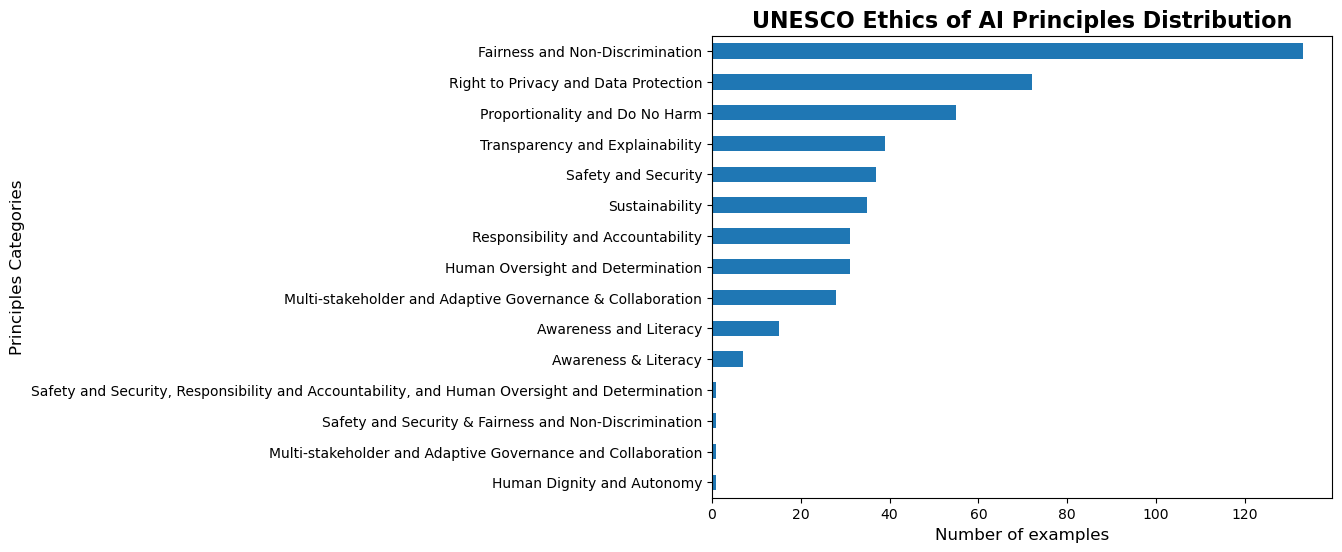

In [8]:
# Format the UNESCO data for plotting
unesco_principles_counts = unesco_df["principle"].value_counts()
unesco_principles_counts_sorted = unesco_principles_counts.sort_values(ascending=True)

# Plot the data
unesco_principles_counts_sorted.plot(kind="barh");

# Add a title and axis labels
plt.title("UNESCO Ethics of AI Principles Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Number of examples", fontsize=12)
plt.ylabel("Principles Categories", fontsize=12)

# Save the plot as a png file
plt.savefig(r"C:\Users\raust\OneDrive\Documents\0BrainStation\BrainStation_DataScience\Week22_IndustrySprint2\Datasets\unesco_principles.png", dpi=300)
plt.show()

In [9]:
# Load the MONTREAL TRAIN CSV dataset
montreal1_df = pd.read_csv(file_path2a)
# print(montreal1_df.head())
#len(montreal1_df) #preliminary check. # 1936 rows

# count/eliminate NULLS
# montreal1_df.isna().sum() # There are 0 NULLS

# count/eliminate duplicates
#montreal1_df.duplicated(keep='first').sum() #total # of duplicated rows # There are 0 duplicates
#montreal1_df.drop_duplicates(keep='first', inplace=True)
# len(montreal1_df) #sanity check to make sure duplicates are dropped.

#print(montreal1_df.info())
# print("Montreal Accord Principles: ", montreal1_df["principle"].unique())
montreal1_principle_counts = montreal1_df["principle"].value_counts()
min_count = 10
mtl1_principle_counts_filtered = montreal1_principle_counts[montreal1_principle_counts >= min_count]
mtl1_principle_counts_filtered

principle
Principle of Well-being                                     146
Principle of Equity                                         138
Principle of Protecting Privacy and Private Life            131
Principle of Respect for Autonomy                           120
Principle of Inclusion of Diversity                         117
Principle of Sustainable Development                        116
Principle of Solidarity                                     112
Principle of Responsibility                                 108
Principle of Democratic Participation                       108
Principle of Caution                                        105
Democratic Participation                                     27
Protecting Privacy and Private Life                          27
Solidarity                                                   27
Inclusion of Diversity                                       27
Equity                                                       27
Respect for Autonomy          

In [10]:
len(mtl1_principle_counts_filtered)

22

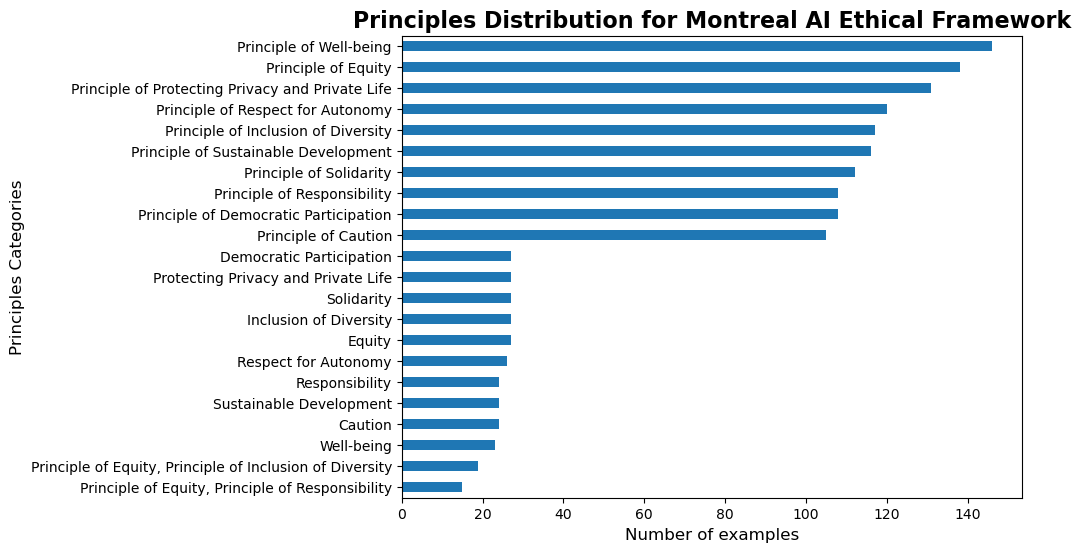

In [11]:
# Format the MONTREAL TRAIN data for plotting
montreal1_principles_counts_sorted = mtl1_principle_counts_filtered.sort_values(ascending=True)

# Plot the data
montreal1_principles_counts_sorted.plot(kind="barh");

# Add a title and axis labels
plt.title("Principles Distribution for Montreal AI Ethical Framework", fontsize=16, fontweight='bold')
plt.xlabel("Number of examples", fontsize=12)
plt.ylabel("Principles Categories", fontsize=12)

# Save the plot as a png file
plt.savefig(r"C:\Users\raust\OneDrive\Documents\0BrainStation\BrainStation_DataScience\Week22_IndustrySprint2\Datasets\montreal_principles.png", dpi=300)
plt.show()

In [12]:
# Load the MONTREAL EVALUATION CSV dataset
montreal2_df = pd.read_csv(file_path2b)
# print(montreal2_df.head())
#len(montreal2_df) #preliminary check. # There are 19 rows

# count/eliminate NULLS
#montreal2_df.isna().sum() # There were no NULLS

# count/eliminate duplicates
#montreal2_df.duplicated(keep='first').sum() #total # of duplicated rows # There were no duplicated rows
#montreal2_df.drop_duplicates(keep='first', inplace=True)
#len(montreal2_df) #sanity check to make sure duplicates are dropped.

# print(montreal2_df.info())
# print("Montreal Accord Principles: ", montreal2_df["principle"].unique())
montreal2_df["principle"].value_counts()

principle
Principle of Well-being                                                                                          2
Principle of Solidarity                                                                                          2
Principle of Protecting Privacy and Private Life, Principle of Well-being, Principle of Respect for Autonomy     1
Principle of Sustainable Development                                                                             1
Principle of Responsibility, Principle of Sustainable Development, Principle of Caution                          1
Principle of Responsibility                                                                                      1
Principle of Respect for Autonomy, Principle of Democratic Participation                                         1
Principle of Respect for Autonomy                                                                                1
Principle of Caution                                                  

In [13]:
len(montreal2_df["principle"].value_counts())

17

Text(0, 0.5, 'Principles Categories')

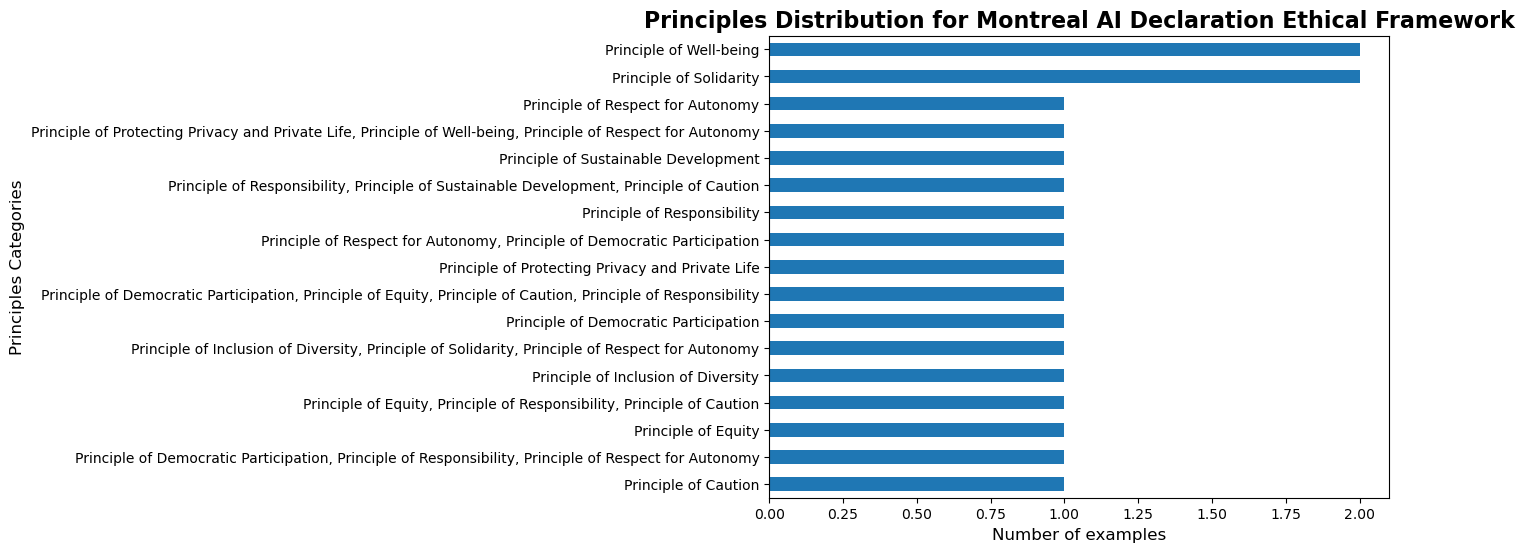

In [14]:
# Format the MONTREAL EVALUATION data for plotting
montreal2_principles_counts = montreal2_df["principle"].value_counts()
montreal2_principles_counts_sorted = montreal2_principles_counts.sort_values(ascending=True)

# Plot the data
montreal2_principles_counts_sorted.plot(kind="barh");

# Add a title and axis labels
plt.title("Principles Distribution for Montreal AI Declaration Ethical Framework", fontsize=16, fontweight='bold')
plt.xlabel("Number of examples", fontsize=12)
plt.ylabel("Principles Categories", fontsize=12)

In [15]:
# Load the Diversity, Equity, and Inclusion CSV dataset
dei_df = pd.read_csv(file_path3)
# print(dei_df.head())
#len(dei_df) #preliminary check. # There are 198 rows

# count/eliminate NULLS
#dei_df.isna().sum() # There are no NULLS

# count/eliminate duplicates
#dei_df.duplicated(keep='first').sum() #total # of duplicated rows # There are no duplicated rows
#dei_df.drop_duplicates(keep='first', inplace=True)
#len(dei_df) #sanity check to make sure duplicates are dropped.

# print(dei_df.info())
# print("DEI Principles: ", dei_df["principle"].unique())
dei_df["principle"].value_counts()

principle
Recognition & Credit               19
Interview & Selection Processes    18
Accommodation Requests             17
Language & Accessibility           17
Team Formation & Collaboration     16
Microaggression Response           16
Mentorship & Development           16
Inclusive Communication            16
Customer/Client Interactions       15
Allyship & Intervention            13
Celebrations & Social Events       12
Conflict Resolution                12
Accessibility                       1
Psychological Safety                1
Fairness                            1
Intersectionality                   1
Inclusion                           1
Equity                              1
Empathy                             1
Cultural Competence                 1
Belonging                           1
Allyship                            1
Unconscious Bias                    1
Name: count, dtype: int64

In [16]:
len(dei_df["principle"].value_counts())

23

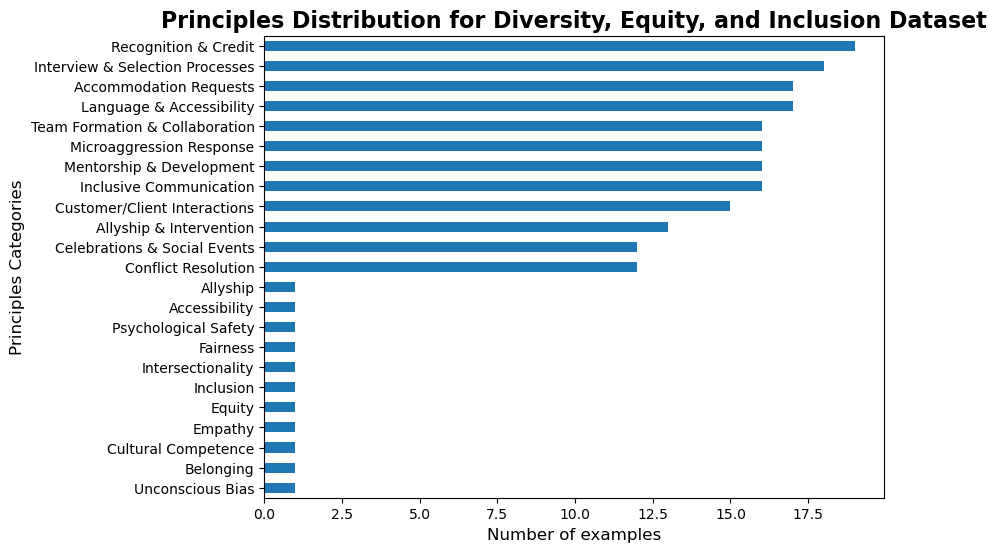

In [17]:
# Format the DIVERSITY, EQUITY, and INCLUSION data for plotting
dei_principles_counts = dei_df["principle"].value_counts()
dei_principles_counts_sorted = dei_principles_counts.sort_values(ascending=True)

# Plot the data
dei_principles_counts_sorted.plot(kind="barh");

# Add a title and axis labels
plt.title("Principles Distribution for Diversity, Equity, and Inclusion Dataset", fontsize=16, fontweight='bold')
plt.xlabel("Number of examples", fontsize=12)
plt.ylabel("Principles Categories", fontsize=12)

# Save the plot as a png file
plt.savefig(r"C:\Users\raust\OneDrive\Documents\0BrainStation\BrainStation_DataScience\Week22_IndustrySprint2\Datasets\dei_principles.png", dpi=300)
plt.show()